# **Homework ML**

##############################

## 1. Preprocessing

##############################

### Import Libraries

In this cell, we import all the necessary libraries for the preprocessing part

In [ ]:
# Dataset download
import kagglehub
import time

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing and data splitting
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

### Dataset Download and Loading

In this cell, we download the dataset from KaggleHub and load it into a DataFrame:

- The `dataset_download` function gives us the latest version of the dataset.
- We specify the path to the CSV file (to reach the correct folder with the CSV) and read it using `pd.read_csv`.
- Finally, we print the dataset dimensions.

In [ ]:
# Download the latest version of the dataset
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

# Load the CSV file in df
csv_path = path + "/UCI_Credit_Card.csv"
df = pd.read_csv(csv_path)

print(f"\nDimensions: {df.shape[0]} rows × {df.shape[1]} columns")

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.

Dimensions: 30000 rows × 25 columns


### Basic Dataset Analysis

In this cell, we explore the dataset:

- `df.info()` tells us general information about the dataset, including data types and non-null counts.
- `df.describe()` displays statistics for the features.
- We visualize the distribution of the target variable `default.payment.next.month`.
- We also calculate and display the percentage of 0 and 1 in the target variable.
- Then, we show the dataset to see some rows.


General info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2        

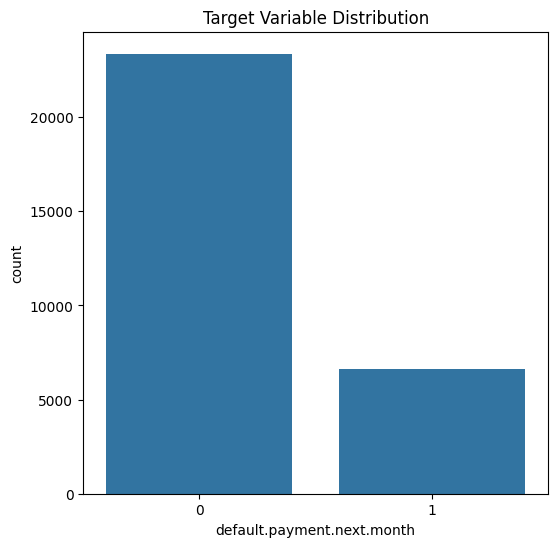


Target class percentages:
default.payment.next.month
0    77.88%
1    22.12%
Name: proportion, dtype: object


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [ ]:
print("General info:")
df.info()

print("\nDescriptive statistics:")
df.describe()

target_col = "default.payment.next.month"

# Plot the distribution of the target variable
plt.figure(figsize=(6, 6))
sns.countplot(x=target_col, data=df)
plt.title("Target Variable Distribution")
plt.show()

# Target class percentages
print("\nTarget class percentages:")
percents = (df[target_col].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(percents)

df

### Column Cleaning and Value Correction

In this cell, we clean and correct dataset columns:

- We remove the `ID` column since it is not useful for prediction.  
- We fix invalid values:  
  - `EDUCATION`: values 0, 5, and 6 are replaced with 4 (`others`).  
  - `MARRIAGE`: value 0 is replaced with 3 (`others`).  
- We check all `PAY_i` columns:  
  - Replace 0 with -1 (on-time payment).  
  - Clip any values outside the range [-1, 9].  
- Finally, we check if the target column only contains 0 and 1.

In [ ]:
# Remove ID column (not useful for prediction)
df = df.drop(columns=["ID"])

# Fix EDUCATION column (invalid values 0, 5, 6 → 4 = 'others')
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# Fix MARRIAGE column (invalid value 0 → 3 = 'others')
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

# Valid values: -1, 1, 2, ..., 9 (0 is invalid)
valid_values = [-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]

def check_and_fix(column_name):
    values = df[column_name].unique()

    if 0 in values:
        print(f"Found value 0 in {column_name}. Replacing it with -1 (on-time payment)\n")
        df[column_name] = df[column_name].replace(0, -1)

# Check all PAY_i columns
for col in ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
    check_and_fix(col)

for col in ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]:
    if (df[col] < 0).any():
        print(f"Negative values found in {col}, clipping to 0\n")
        df[col] = df[col].clip(lower=0)

# Check target columns
target_values = df[target_col]

if not all(v in [0, 1] for v in target_values):
    print("Found invalid values in the target column. Removing them")
    df = df[df[target_col].isin([0, 1])]
else:
    print("Target column is correct (contains only 0 and 1)")

Found value 0 in PAY_0. Replacing it with -1 (on-time payment)

Found value 0 in PAY_2. Replacing it with -1 (on-time payment)

Found value 0 in PAY_3. Replacing it with -1 (on-time payment)

Found value 0 in PAY_4. Replacing it with -1 (on-time payment)

Found value 0 in PAY_5. Replacing it with -1 (on-time payment)

Found value 0 in PAY_6. Replacing it with -1 (on-time payment)

Negative values found in BILL_AMT1, clipping to 0

Negative values found in BILL_AMT2, clipping to 0

Negative values found in BILL_AMT3, clipping to 0

Negative values found in BILL_AMT4, clipping to 0

Negative values found in BILL_AMT5, clipping to 0

Negative values found in BILL_AMT6, clipping to 0

Target column is correct (contains only 0 and 1)


### Feature Preprocessing and Standardization

In this cell, we prepare the dataset for modeling:

- Separate the features (`X`) from the target column (`y`).

- Standardize the numerical features using `RobustScaler`, which is robust to outliers.  
  This ensures that extreme values do not dominate the training and that all numerical features are on a similar scale, improving model performance.

- Apply one-hot encoding to the categorical features (`SEX`, `EDUCATION`, `MARRIAGE`).  
  This converts categorical variables into separate binary columns, and then these new columns are converted into integers (`0` or `1` and not `True` or `False`).

- Display the resulting dataset to see the changes.


In [ ]:
# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Standardize numerical features with RobustScaler (very useful for outlier in this dataset)
scaler = RobustScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Apply one-hot encoding
X = pd.get_dummies(X, columns=["SEX", "EDUCATION", "MARRIAGE"])

# Convert only the new dummy columns to integers
dummy_cols = [col for col in X.columns if col.startswith(("SEX_", "EDUCATION_", "MARRIAGE_"))]
X[dummy_cols] = X[dummy_cols].astype(int)

# View some of the changed lines
X

,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT6,SEX_-1.0,SEX_0.0,EDUCATION_-1.0,EDUCATION_0.0,EDUCATION_1.0,EDUCATION_2.0,MARRIAGE_-1.0,MARRIAGE_0.0,MARRIAGE_1.0
0,-0.631579,-0.769231,3.0,3.0,0.0,0.0,-1.0,-1.0,-0.290695,-0.296584,...,-0.386374,0,1,0,1,0,0,1,0,0
1,-0.105263,-0.615385,0.0,3.0,0.0,0.0,0.0,3.0,-0.310071,-0.319150,...,0.128791,0,1,0,1,0,0,0,1,0
2,-0.263158,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.107937,-0.117549,...,0.901539,0,1,0,1,0,0,0,1,0
3,-0.473684,0.230769,0.0,0.0,0.0,0.0,0.0,0.0,0.387339,0.443008,...,-0.128791,0,1,0,1,0,0,1,0,0
4,-0.473684,1.769231,0.0,0.0,0.0,0.0,0.0,0.0,-0.216654,-0.254500,...,-0.211475,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0.421053,0.384615,0.0,0.0,0.0,0.0,0.0,0.0,2.621763,2.812369,...,-0.128791,1,0,0,0,1,0,1,0,0
29996,0.052632,0.692308,0.0,0.0,0.0,0.0,0.0,0.0,-0.325795,-0.317462,...,-0.386374,1,0,0,0,1,0,0,1,0
29997,-0.578947,0.230769,5.0,4.0,3.0,0.0,0.0,0.0,-0.296172,-0.292422,...,0.412132,1,0,0,1,0,0,0,1,0
29998,-0.315789,0.538462,2.0,0.0,0.0,0.0,0.0,0.0,-0.352286,0.937030,...,0.078305,1,0,0,0,1,0,1,0,0


## 2. ML Models to train

### Import Libraries for Modeling

In this cell, we import all the necessary libraries for the modeling phase

In [ ]:
# Model evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

# Performance timing
import time

# Hyperparameter GridSearch
from sklearn.model_selection import GridSearchCV

# Models to train
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Utils
from sklearn.tree import plot_tree

### Train-Test Split

In this cell, we split the dataset:

- The data is divided in 80% for training and 20% for testing using `train_test_split`, with stratification (`stratify=y`) to keep class balance.  
- We show the number of samples in each set and draw a graph of the distribution.  

A separate validation set is not created. This is because, in the cells dedicated to hyperparameter tuning, GridSearchCV with k-fold cross-validation will be used. This procedure automatically creates validation folds from the training set.  
This approach is applied to all implemented algorithms except Naive Bayes, which does not require hyperparameter tuning.

Dataset split:
Training set: 24000 samples
Test set:     6000 samples



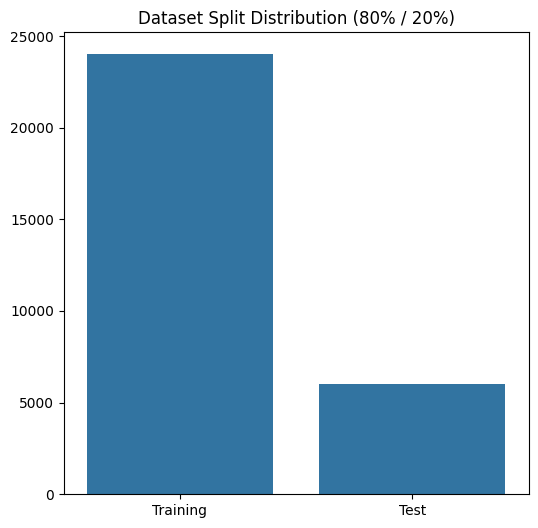

In [ ]:
# Split the dataset into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9, stratify=y)

# Show the number of samples in each set
print("Dataset split:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples\n")

split_sizes = {"Training": len(X_train), "Test": len(X_test)}

plt.figure(figsize=(6, 6))
sns.barplot(x=list(split_sizes.keys()), y=list(split_sizes.values()))
plt.title("Dataset Split Distribution (80% / 20%)")
plt.show()

##############################

## Naive Bayes

##############################

### Naive Bayes - Training and Prediction

In this cell, we train and test the Naive Bayes model:

- We initialize the `GaussianNB` classifier from scikit-learn.  
- The model is trained on the training set, and the training time is measured to evaluate efficiency.  
- After training, we use the model to predict the target values on the test set.

A validation set is not used here because the Naive Bayes algorithm does not require hyperparameter tuning, its parameters are estimated directly from the data based on probabilistic assumptions.
  (While `GaussianNB` in scikit-learn provides some parameters like `var_smoothing`, these are optimization parameters rather than true hyperparameters that require grid search.)

In [ ]:
# Initialize the model
nb_model = GaussianNB()

# Train the model
print("Training final Naive Bayes model on full training set...")
start_time = time.time()
nb_model.fit(X_train, y_train)
total_time_nb = time.time() - start_time
print(f"Training completed in {total_time_nb:.4f} seconds")

# Predictions on test set
y_pred_nb = nb_model.predict(X_test)

Training final Naive Bayes model on full training set...
Training completed in 0.0293 seconds


### Naive Bayes - Model Evaluation

In this cell, we evaluate the performance of the Naive Bayes classifier:

- We calculate some simple classification metrics: accuracy, precision, recall, F1 score and AUC.  
- We show the confusion matrix to visualize the number of correct and incorrect predictions.  
- We plot the ROC curve to analyze the trade-off between true positive and false positive rates.  
- Finally, we compare training and test accuracies to check potential overfitting.

Naive Bayes Evaluation Results:

Accuracy:  0.7505
Precision: 0.4524
Recall:    0.6081
F1 Score:  0.5188
AUC:       0.7528



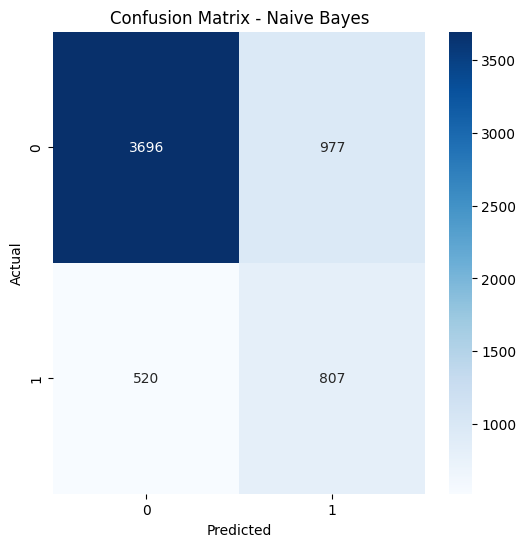

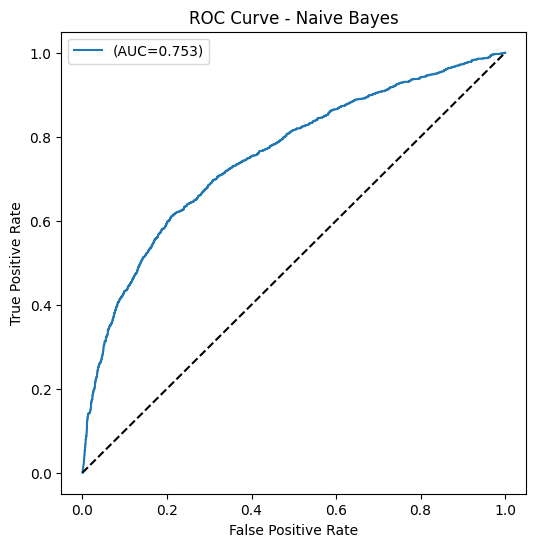


Training Accuracy:    0.7511
Validation Accuracy:    0.7505
Overfitting Gap:        0.0006


In [ ]:
print("Naive Bayes Evaluation Results:\n")

# Basic metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy:  {accuracy_nb:.4f}")

precision_nb = precision_score(y_test, y_pred_nb)
print(f"Precision: {precision_nb:.4f}")

recall_nb = recall_score(y_test, y_pred_nb)
print(f"Recall:    {recall_nb:.4f}")

f1_nb = f1_score(y_test, y_pred_nb)
print(f"F1 Score:  {f1_nb:.4f}")

# Compute predicted probabilities for ROC/AUC
# Instead of using y_pred_nb (which contains only class labels 0/1),
# we use predict_proba() to get the probability that each sample belongs to class 1.
# The ROC curve and AUC metric require these probability scores
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]
auc_nb = roc_auc_score(y_test, y_prob_nb)
print(f"AUC:       {auc_nb:.4f}\n")

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print()

# ROC Curve
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
plt.figure(figsize=(6, 6))
plt.plot(fpr_nb, tpr_nb, label=f"(AUC={auc_nb:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.show()

# Training vs Test Performance
y_train_pred_nb = nb_model.predict(X_train)
train_acc_nb = accuracy_score(y_train, y_train_pred_nb)
test_acc_nb = accuracy_nb
overfit_gap_nb = abs(train_acc_nb - test_acc_nb)

print(f"\nTraining Accuracy:    {train_acc_nb:.4f}")
print(f"Validation Accuracy:    {test_acc_nb:.4f}")
print(f"Overfitting Gap:        {overfit_gap_nb:.4f}")

##############################

## Logistic Regression

##############################

### Logistic Regression - Hyperparameter Tuning

In this cell, we optimize the Logistic Regression model:

- We define a hyperparameter grid including:
  - `max_iter`: maximum number of iterations for the solver to converge.
  - `fit_intercept`: whether to include the intercept term.
  - `tol`: tolerance for stopping criteria (smaller values → more precise but slower convergence).
  - `class_weight`: adjust weights inversely proportional to class frequencies to handle class imbalance.
- A base Logistic Regression model is initialized.  
- We perform a GridSearchCV with 5-fold cross-validation on the training set to find the best hyperparameter configuration.  
- The validation set is implicitly used during cross-validation to evaluate performance on different folds.  
- Finally, we show the best hyperparameters found and the mean cross-validated accuracy.

In [ ]:
# Define hyperparameter grid with additional parameters
param_grid_lr = {
    "max_iter": [100, 200, 500, 1000, 5000, 10000],  # Maximum number of iterations
    "fit_intercept": [True, False],                  # Include or not the intercept term
    "tol": [0.01, 0.001, 0.0001],                    # Tolerance for stopping criteria (smaller → more precise, slower)
    "class_weight": [None, "balanced"]               # Adjust weights inversely proportional to class frequencies
}

# Initialize base Logistic Regression model
base_lr = LogisticRegression(random_state=9)

# GridSearch with 5-fold cross-validation
grid_search_lr = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("Starting Logistic Regression hyperparameter tuning with 5-fold cross-validation...")
start_time = time.time()
grid_search_lr.fit(X_train, y_train)
total_time = time.time() - start_time
print(f"Hyperparameter tuning completed in {total_time:.2f} seconds")

# Best hyperparameters and corresponding cross-validation accuracy
best_params_lr = grid_search_lr.best_params_
best_score_lr = grid_search_lr.best_score_

print("\nBest Hyperparameters for Logistic Regression:")
print(best_params_lr)
print(f"Mean cross-validated accuracy: {best_score_lr:.4f}")

Starting Logistic Regression hyperparameter tuning with 5-fold cross-validation...
Hyperparameter tuning completed in 61.04 seconds

Best Hyperparameters for Logistic Regression:
{'class_weight': None, 'fit_intercept': True, 'max_iter': 100, 'tol': 0.01}
Mean cross-validated accuracy: 0.8165


### Logistic Regression - Training and Prediction

In this cell, we train and test the Logistic Regression model:

- We initialize the `LogisticRegression` classifier using the best hyperparameters obtained from the Grid Search, including `max_iter`, `fit_intercept`, `tol`, and `class_weight`.
- After training, the model is used to predict the target values on the test set.

Unlike Naive Bayes, Logistic Regression benefits from hyperparameter tuning, including solver configuration, number of iterations, stopping tolerance, inclusion of intercept, and handling of class imbalance.

In [ ]:
# Initialize model with best hyperparameters from GridSearch
lr_model = LogisticRegression(
    max_iter=best_params_lr['max_iter'],
    fit_intercept=best_params_lr['fit_intercept'],
    tol=best_params_lr['tol'],
    class_weight=best_params_lr['class_weight'],
    random_state=9
)

# Train the model
print("Training final Logistic Regression model on full training set...")
start_time = time.time()
lr_model.fit(X_train, y_train)
total_time_lr = time.time() - start_time
print(f"Training completed in {total_time_lr:.4f} seconds")

# Predictions on test set
y_pred_lr = lr_model.predict(X_test)

Training final Logistic Regression model on full training set...
Training completed in 0.1187 seconds


### Logistic Regression - Model Evaluation

In this cell, we evaluate the performance of the Logistic Regression classifier:

- We compute the main classification metrics: accuracy, precision, recall, F1 score and AUC.  
- We obtain predicted probabilities to valuate the model using ROC and AUC.
- We visualize the confusion matrix.
- We plot the ROC curve to analyzetrue positive and false positive rates.  
- Finally, we compare training and test accuracies to see a potential overfitting.


Logistic Regression Evaluation Results:

Accuracy:  0.8142
Precision: 0.6550
Recall:    0.3376
F1 Score:  0.4455
AUC:       0.7498



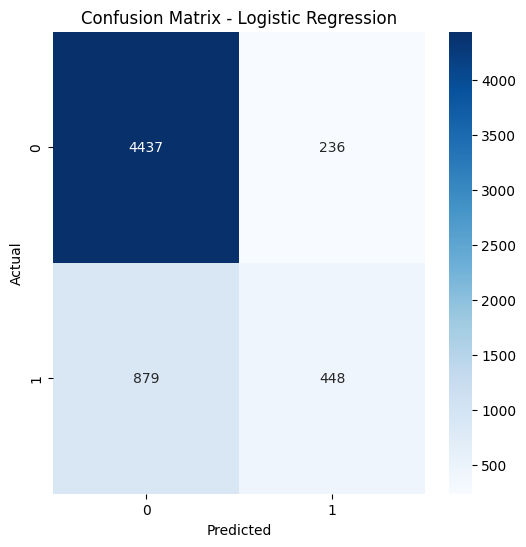

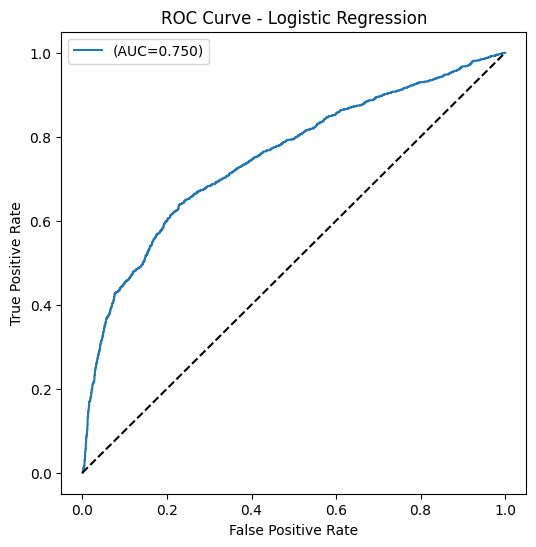


Training Accuracy:    0.8169
Validation Accuracy:    0.8142
Overfitting Gap:        0.0027


In [ ]:
print("Logistic Regression Evaluation Results:\n")

# Basic metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy:  {accuracy_lr:.4f}")

precision_lr = precision_score(y_test, y_pred_lr)
print(f"Precision: {precision_lr:.4f}")

recall_lr = recall_score(y_test, y_pred_lr)
print(f"Recall:    {recall_lr:.4f}")

f1_lr = f1_score(y_test, y_pred_lr)
print(f"F1 Score:  {f1_lr:.4f}")

# Compute predicted probabilities for ROC/AUC
# Instead of using y_pred_nb (which contains only class labels 0/1),
# we use predict_proba() to get the probability that each sample belongs to class 1.
# The ROC curve and AUC metric require these probability scores
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"AUC:       {auc_lr:.4f}\n")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print()

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f"(AUC={auc_lr:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

# Training vs Test Performance
y_train_pred_lr = lr_model.predict(X_train)
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
test_acc_lr = accuracy_lr
overfit_gap_lr = abs(train_acc_lr - test_acc_lr)

print(f"\nTraining Accuracy:    {train_acc_lr:.4f}")
print(f"Validation Accuracy:    {test_acc_lr:.4f}")
print(f"Overfitting Gap:        {overfit_gap_lr:.4f}")

##############################

## Decision Tree

##############################

### Decision Tree - Hyperparameter Tuning

In this cell, we optimize the Decision Tree classifier:

- We define a hyperparameter grid including `max_depth`, `min_samples_split`, `min_samples_leaf` and `criterion`.
- A base Decision Tree model is initialized with a `random_state` for reproducibility.  
- We perform a `GridSearchCV` with 5-fold cross-validation on the training set to find the best combination.  
- During cross-validation, each fold of the training data serves as a temporary validation set, allowing the model to be evaluated across multiple splits.  
- Finally, we show the best hyperparameters found and the mean cross-validated accuracy with the total tuning time.


In [ ]:
# Define hyperparameter grid
param_grid_dt = {
    "max_depth": [3, 5, 7, 10],         # Maximum depth of the tree; limits how deep the tree can grow (controls overfitting)
    "min_samples_split": [2, 5, 10],    # Minimum number of samples required to split an internal node
    "min_samples_leaf": [1, 2, 4],      # Minimum number of samples required to be at a leaf node
    "criterion": ["gini", "entropy"]    # Function to measure the quality of a split
}

# Initialize base Decision Tree model
base_dt = DecisionTreeClassifier(random_state=9)

# GridSearch with 5-fold cross-validation
grid_search_dt = GridSearchCV(
    estimator=base_dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Starting Decision Tree hyperparameter tuning with 5-fold cross-validation...")
start_time = time.time()
grid_search_dt.fit(X_train, y_train)
total_time = time.time() - start_time
print(f"Hyperparameter tuning completed in {total_time:.2f} seconds")

# Best hyperparameters and corresponding cross-validation accuracy
best_params_dt = grid_search_dt.best_params_
best_score_dt = grid_search_dt.best_score_

print("\nBest Hyperparameters for Decision Tree:")
print(best_params_dt)
print(f"Mean cross-validated accuracy: {best_score_dt:.4f}")

Starting Decision Tree hyperparameter tuning with 5-fold cross-validation...
Hyperparameter tuning completed in 80.88 seconds

Best Hyperparameters for Decision Tree:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mean cross-validated accuracy: 0.8207


### Decision Tree - Training and Prediction

In this cell, we train and evaluate the final Decision Tree model:

- We initialize the `DecisionTreeClassifier` using the best hyperparameters found during the Grid Search.  
- The model is trained on the training set, and the training time is measured.  
- After training, the model is used to predict the target label on the test set and then we plot the decision tree.

Training final Decision Tree model on full training set...
Training completed in 0.1457 seconds



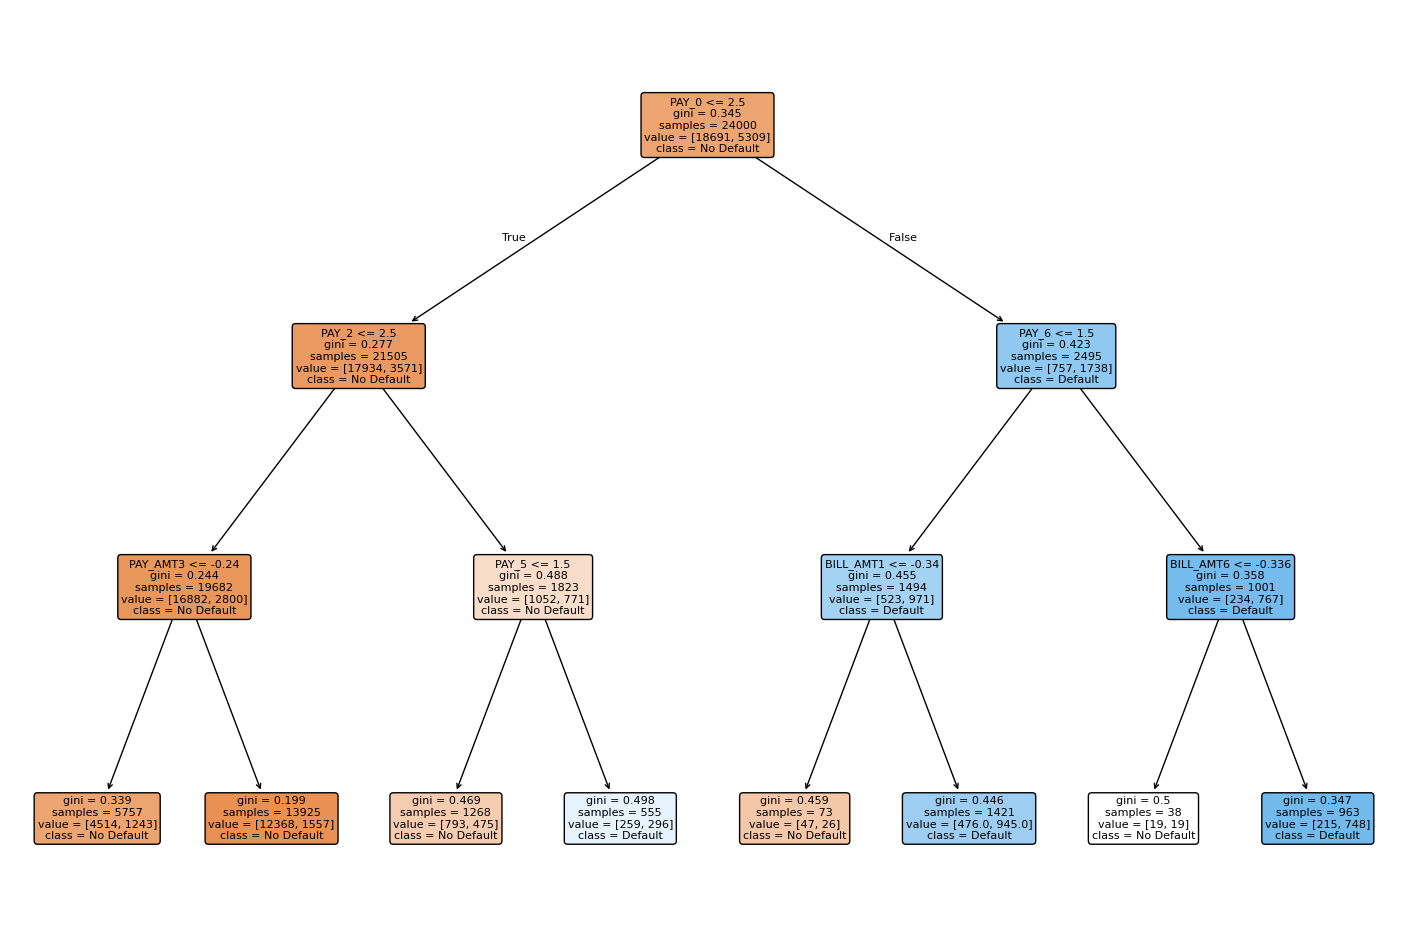

In [ ]:
# Initialize model with best hyperparameters
dt_model = DecisionTreeClassifier(
    max_depth=best_params_dt["max_depth"],
    min_samples_split=best_params_dt["min_samples_split"],
    min_samples_leaf=best_params_dt["min_samples_leaf"],
    criterion=best_params_dt["criterion"],
    random_state=9
)

# Train the model
print("Training final Decision Tree model on full training set...")
start_time = time.time()
dt_model.fit(X_train, y_train)
total_time_dt = time.time() - start_time
print(f"Training completed in {total_time_dt:.4f} seconds\n")

# Predictions on test set
y_pred_dt = dt_model.predict(X_test)

# Plot decision tree
plt.figure(figsize=(18, 12))
plot_tree(dt_model, feature_names=X_train.columns,
          class_names=["No Default", "Default"],
          filled=True, rounded=True, fontsize=8)
plt.show()

### Decision Tree - Model Evaluation

(Same as Logistic Regression)

Decision Tree Evaluation Results:

Accuracy:  0.8183
Precision: 0.6604
Recall:    0.3677
F1 Score:  0.4724
AUC:       0.7199



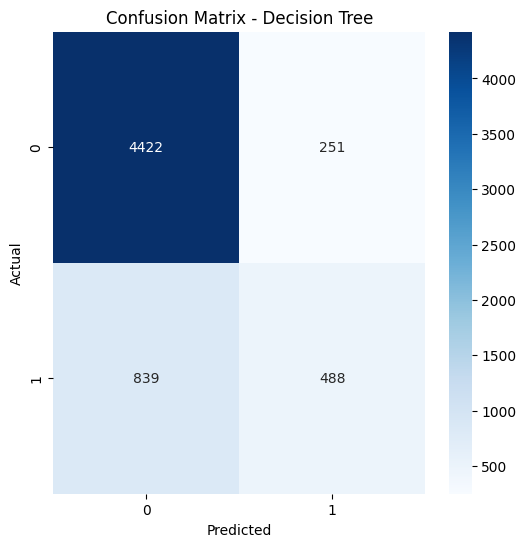

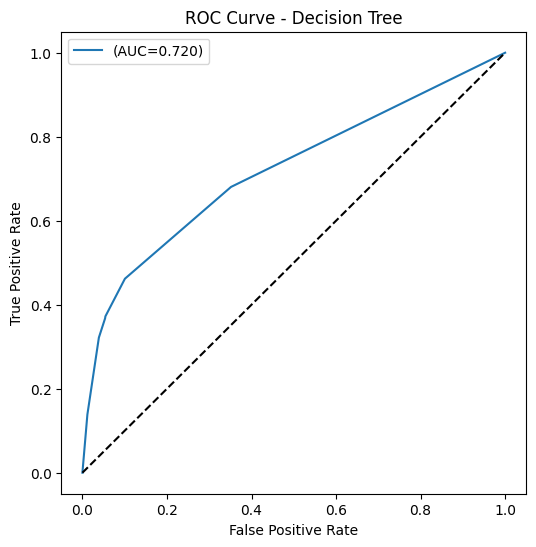


Training Accuracy:    0.8221
Validation Accuracy:    0.8183
Overfitting Gap:        0.0038


In [ ]:
print("Decision Tree Evaluation Results:\n")

# Basic metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy:  {accuracy_dt:.4f}")

precision_dt = precision_score(y_test, y_pred_dt)
print(f"Precision: {precision_dt:.4f}")

recall_dt = recall_score(y_test, y_pred_dt)
print(f"Recall:    {recall_dt:.4f}")

f1_dt = f1_score(y_test, y_pred_dt)
print(f"F1 Score:  {f1_dt:.4f}")

# Predicted probabilities for ROC/AUC
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
auc_dt = roc_auc_score(y_test, y_prob_dt)
print(f"AUC:       {auc_dt:.4f}\n")

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print()

# ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.figure(figsize=(6, 6))
plt.plot(fpr_dt, tpr_dt, label=f"(AUC={auc_dt:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

# Training vs Test Performance
y_train_pred_dt = dt_model.predict(X_train)
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
test_acc_dt = accuracy_score(y_test, y_pred_dt)
overfit_gap_dt = abs(train_acc_dt - test_acc_dt)

print(f"\nTraining Accuracy:    {train_acc_dt:.4f}")
print(f"Validation Accuracy:    {test_acc_dt:.4f}")
print(f"Overfitting Gap:        {overfit_gap_dt:.4f}")

##############################

## Random Forest

##############################

### Random Forest - Hyperparameter Tuning

In this cell, we optimize the Random Forest classifier:

- We define a hyperparameter grid including the number of trees, tree depth, minimum samples for splitting and leaf nodes, sampling strategy, and number of features considered at each split.  
- A base Random Forest model is initialized with a fixed `random_state` to ensure reproducibility.  
- We perform a `GridSearchCV` with 3-fold cross-validation on the training set to find the best combination.  
- During cross-validation, each fold of the training data serves as a temporary validation set, allowing the model to be evaluated across multiple splits.  
- Finally, we show the best hyperparameters found and the mean cross-validated accuracy with the total tuning time.

In [ ]:
# Define hyperparameter grid
param_grid_rf = {
    "n_estimators": [10, 20],           # Number of trees in the forest (more trees = more stable but slower)
    "max_depth": [3, 5],                # Maximum depth of each individual tree (limits overfitting)
    "min_samples_split": [2, 3],        # Minimum number of samples required to split an internal node
    "min_samples_leaf": [1, 2],         # Minimum number of samples required to be at a leaf node
    "criterion": ["gini", "entropy"],   # Split quality metric
    "max_features": ["sqrt", None]      # Number of features to consider when looking for the best split:
                                        # "sqrt" = sqrt(total_features), None = use all features
}

# Initialize base Random Forest model
base_rf = RandomForestClassifier(random_state=9)

# GridSearch with 3-fold cross-validation
grid_search_rf = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

print("Starting Random Forest hyperparameter tuning with 3-fold cross-validation...")
start_time = time.time()
grid_search_rf.fit(X_train, y_train)
total_time = time.time() - start_time
print(f"Hyperparameter tuning completed in {total_time:.2f} seconds")

# Best hyperparameters and cross-validated score
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print("\nBest Hyperparameters for Random Forest:")
print(best_params_rf)
print(f"Mean cross-validated accuracy: {best_score_rf:.4f}")

Starting Random Forest hyperparameter tuning with 3-fold cross-validation...
Hyperparameter tuning completed in 134.62 seconds

Best Hyperparameters for Random Forest:
{'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 10}
Mean cross-validated accuracy: 0.8215


### Random Forest - Training and Prediction

(Same as Decision Tree)

In [ ]:
# Initialize model with best hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=best_params_rf["n_estimators"],
    max_depth=best_params_rf["max_depth"],
    min_samples_split=best_params_rf["min_samples_split"],
    min_samples_leaf=best_params_rf["min_samples_leaf"],
    criterion=best_params_rf["criterion"],
    max_features=best_params_rf["max_features"],
    random_state=9
)

# Train the model
print("Training final Random Forest model on full training set...")
start_time = time.time()
rf_model.fit(X_train, y_train)
total_time_rf = time.time() - start_time
print(f"Training completed in {total_time_rf:.4f} seconds")

# Predictions on test set
y_pred_rf = rf_model.predict(X_test)

Training final Random Forest model on full training set...
Training completed in 0.4196 seconds


### Random Forest - Model Evaluation

(Same as Decision Tree)

Random Forest Evaluation Results:

Accuracy:  0.8202
Precision: 0.6802
Recall:    0.3527
F1 Score:  0.4645
AUC:       0.7718



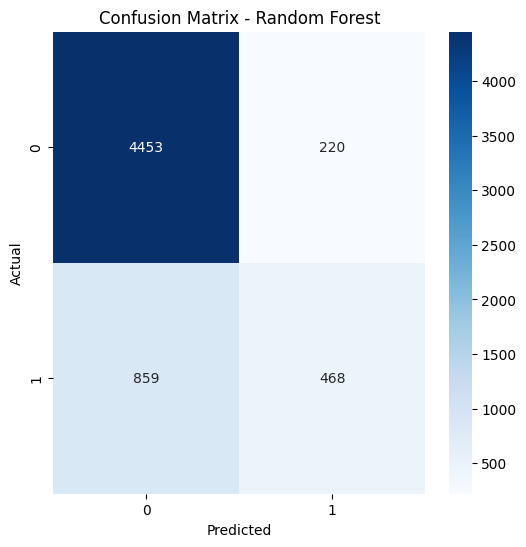

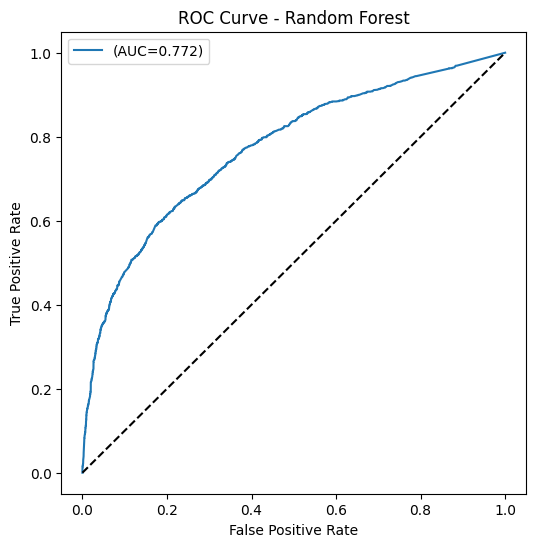


Training Accuracy:    0.8228
Validation Accuracy:    0.8202
Overfitting Gap:        0.0026


In [ ]:
print("Random Forest Evaluation Results:\n")

# Basic metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy:  {accuracy_rf:.4f}")

precision_rf = precision_score(y_test, y_pred_rf)
print(f"Precision: {precision_rf:.4f}")

recall_rf = recall_score(y_test, y_pred_rf)
print(f"Recall:    {recall_rf:.4f}")

f1_rf = f1_score(y_test, y_pred_rf)
print(f"F1 Score:  {f1_rf:.4f}")

# Predicted probabilities for ROC/AUC
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"AUC:       {auc_rf:.4f}\n")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print()

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6, 6))
plt.plot(fpr_rf, tpr_rf, label=f"(AUC={auc_rf:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# Training vs Test Performance
y_train_pred_rf = rf_model.predict(X_train)
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_pred_rf)
overfit_gap_rf = abs(train_acc_rf - test_acc_rf)

print(f"\nTraining Accuracy:    {train_acc_rf:.4f}")
print(f"Validation Accuracy:    {test_acc_rf:.4f}")
print(f"Overfitting Gap:        {overfit_gap_rf:.4f}")

##############################

## SVM Linear

##############################

### Linear SVM - Hyperparameter Tuning

In this cell, we optimize the Linear Support Vector Machine (SVM) classifier:

- We define a hyperparameter grid including the regularization parameter `C` and the parameter `tol`.
- A base Linear SVM model is initialized using a `linear` kernel and a `random_state` for reproducibility.
- We perform a `GridSearchCV` with 3-fold cross-validation on the training set to find the best combination.  
- During cross-validation, each fold of the training data serves as a temporary validation set, allowing the model to be evaluated across multiple splits.  
- Finally, we show the best hyperparameters found and the mean cross-validated accuracy with the total tuning time.

In [ ]:
# Define hyperparameter grid
param_grid_svm_linear = {
    "C": [0.001, 0.01],     # Regularization strength
    "tol": [0.1, 1],         # Tolerance for stopping criterion
}


# Initialize base Linear SVM model
base_svm_linear = SVC(kernel="linear", random_state=9)

# GridSearch with 3-fold cross-validation
grid_search_svm_linear = GridSearchCV(
    estimator=base_svm_linear,
    param_grid=param_grid_svm_linear,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

print("Starting Linear SVM hyperparameter tuning with 3-fold cross-validation...")
start_time = time.time()
grid_search_svm_linear.fit(X_train, y_train)
total_time = time.time() - start_time
print(f"Hyperparameter tuning completed in {total_time:.2f} seconds")

# Best hyperparameters and corresponding cross-validation accuracy
best_params_svm_linear = grid_search_svm_linear.best_params_
best_score_svm_linear = grid_search_svm_linear.best_score_

print("\nBest Hyperparameters for Linear SVM:")
print(best_params_svm_linear)
print(f"Mean cross-validated accuracy: {best_score_svm_linear:.4f}")

Starting Linear SVM hyperparameter tuning with 3-fold cross-validation...
Hyperparameter tuning completed in 109.80 seconds

Best Hyperparameters for Linear SVM:
{'C': 0.001, 'tol': 0.1}
Mean cross-validated accuracy: 0.7982


### Linear SVM - Training and Prediction

(Same as Decision Tree)

In [ ]:
# Initialize model with best hyperparameters
svm_linear_model = SVC(
    kernel="linear",
    C=best_params_svm_linear["C"],
    tol=best_params_svm_linear["tol"],
    random_state=9,
)

# Train the model
print("Training final Linear SVM model on full training set...")
start_time = time.time()
svm_linear_model.fit(X_train, y_train)
total_time_svm_linear = time.time() - start_time
print(f"Training completed in {total_time_svm_linear:.4f} seconds")

# Predictions on test set
y_pred_svm_linear = svm_linear_model.predict(X_test)

Training final Linear SVM model on full training set...
Training completed in 14.8405 seconds


### Linear SVM - Model Evaluation

(Same as Decision Tree)

Linear SVM Evaluation Results:

Accuracy:  0.7930
Precision: 0.5473
Recall:    0.3708
F1 Score:  0.4420
AUC:       0.7354



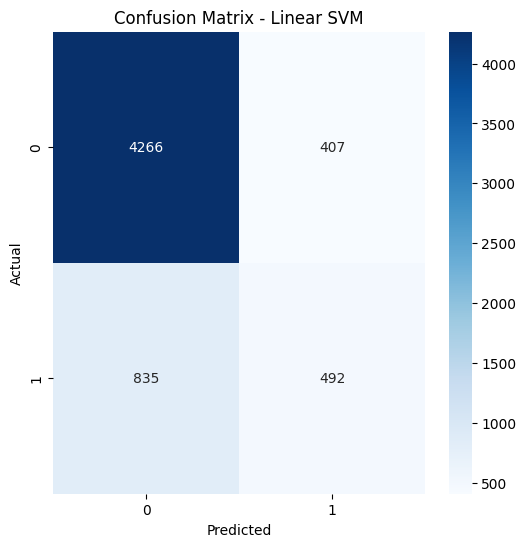

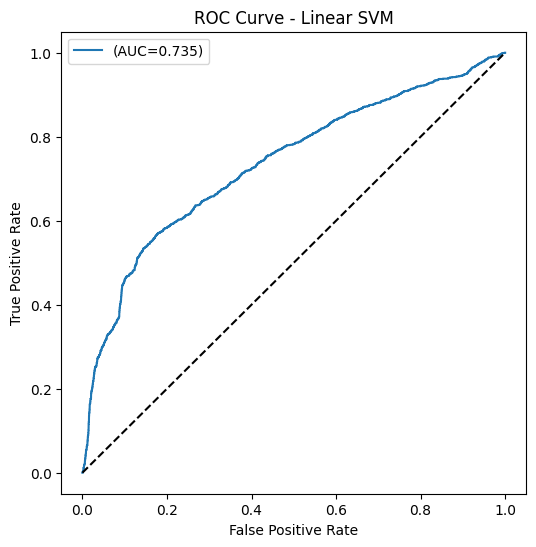


Training Accuracy:    0.7967
Validation Accuracy:    0.7930
Overfitting Gap:        0.0037


In [ ]:
print("Linear SVM Evaluation Results:\n")

# Basic metrics
accuracy_svm_linear = accuracy_score(y_test, y_pred_svm_linear)
print(f"Accuracy:  {accuracy_svm_linear:.4f}")

precision_svm_linear = precision_score(y_test, y_pred_svm_linear)
print(f"Precision: {precision_svm_linear:.4f}")

recall_svm_linear = recall_score(y_test, y_pred_svm_linear)
print(f"Recall:    {recall_svm_linear:.4f}")

f1_svm_linear = f1_score(y_test, y_pred_svm_linear)
print(f"F1 Score:  {f1_svm_linear:.4f}")

# Predicted probabilities for ROC/AUC
y_score_svm_linear = svm_linear_model.decision_function(X_test)
auc_svm_linear = roc_auc_score(y_test, y_score_svm_linear)
print(f"AUC:       {auc_svm_linear:.4f}\n")

# Confusion Matrix
cm_svm_linear = confusion_matrix(y_test, y_pred_svm_linear)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_svm_linear, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print()

# ROC Curve
fpr_svm_linear, tpr_svm_linear, _ = roc_curve(y_test, y_score_svm_linear)
plt.figure(figsize=(6, 6))
plt.plot(fpr_svm_linear, tpr_svm_linear, label=f"(AUC={auc_svm_linear:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Linear SVM")
plt.legend()
plt.show()

# Training vs Test Performance
y_train_pred_svm_linear = svm_linear_model.predict(X_train)
train_acc_svm_linear = accuracy_score(y_train, y_train_pred_svm_linear)
test_acc_svm_linear = accuracy_svm_linear
overfit_gap_svm_linear = abs(train_acc_svm_linear - test_acc_svm_linear)

print(f"\nTraining Accuracy:    {train_acc_svm_linear:.4f}")
print(f"Validation Accuracy:    {test_acc_svm_linear:.4f}")
print(f"Overfitting Gap:        {overfit_gap_svm_linear:.4f}")

##############################

## SVM Kernel-Based

##############################

### RBF SVM - Hyperparameter Tuning

In this cell, we optimize the SVM classifier with an RBF (Radial Basis Function) kernel:

- We define a hyperparameter grid including the regularization parameter C and the parameter tol.
- A base RBF SVM model is initialized with a fixed random_state for reproducibility.  
- We perform a `GridSearchCV` with 3-fold cross-validation on the training set to find the best combination.  
- During cross-validation, each fold of the training data serves as a temporary validation set, allowing the model to be evaluated across multiple splits.  
- Finally, we show the best hyperparameters found and the mean cross-validated accuracy with the total tuning time.


In [ ]:
# Define hyperparameter grid
param_grid_svm_rbf = {
    "C": [0.001, 0.01],       # Regularization strength
    "tol": [0.1, 1],          # Tolerance for stopping criterion
}

# Initialize base RBF SVM model
base_svm_rbf = SVC(kernel="rbf", random_state=9)

# GridSearch with 3-fold cross-validation
grid_search_svm_rbf = GridSearchCV(
    estimator=base_svm_rbf,
    param_grid=param_grid_svm_rbf,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

print("Starting RBF SVM hyperparameter tuning with 3-fold cross-validation...")
start_time = time.time()
grid_search_svm_rbf.fit(X_train, y_train)
total_time = time.time() - start_time
print(f"Hyperparameter tuning completed in {total_time:.2f} seconds")

# Best hyperparameters and cross-validated score
best_params_svm_rbf = grid_search_svm_rbf.best_params_
best_score_svm_rbf = grid_search_svm_rbf.best_score_

print("\nBest Hyperparameters for RBF SVM:")
print(best_params_svm_rbf)
print(f"Mean cross-validated accuracy: {best_score_svm_rbf:.4f}")

Starting RBF SVM hyperparameter tuning with 3-fold cross-validation...
Hyperparameter tuning completed in 147.87 seconds

Best Hyperparameters for RBF SVM:
{'C': 0.01, 'tol': 1}
Mean cross-validated accuracy: 0.8049


### RBF SVM - Training and Prediction

(Same as Decision Tree)

In [ ]:
# Initialize model with best hyperparameters
svm_rbf_model = SVC(
    kernel="rbf",
    C=best_params_svm_rbf["C"],
    tol=best_params_svm_rbf["tol"],
    random_state=9,
    probability=False
)

# Train the model
print("Training final RBF SVM model on full training set...")
start_time = time.time()
svm_rbf_model.fit(X_train, y_train)
total_time_svm_rbf = time.time() - start_time
print(f"Training completed in {total_time_svm_rbf:.4f} seconds")

# Predictions on test set
y_pred_svm_rbf = svm_rbf_model.predict(X_test)

Training final RBF SVM model on full training set...
Training completed in 16.2839 seconds


### RBF SVM - Model Evaluation

(Same as Decision Tree)

RBF SVM Evaluation Results:

Accuracy:  0.8072
Precision: 0.6622
Recall:    0.2615
F1 Score:  0.3749
AUC:       0.7066



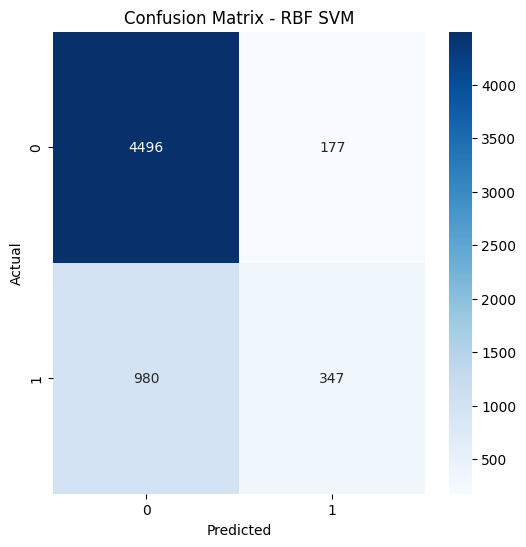

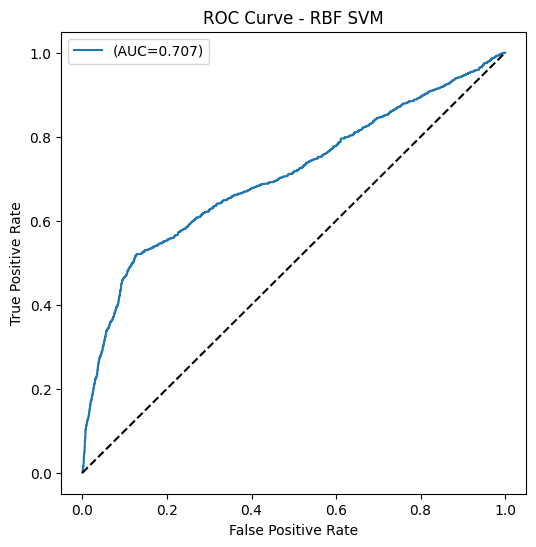


Training Accuracy:    0.8073
Validation Accuracy:    0.8072
Overfitting Gap:        0.0002


In [ ]:
print("RBF SVM Evaluation Results:\n")

# Basic metrics
accuracy_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
print(f"Accuracy:  {accuracy_svm_rbf:.4f}")

precision_svm_rbf = precision_score(y_test, y_pred_svm_rbf)
print(f"Precision: {precision_svm_rbf:.4f}")

recall_svm_rbf = recall_score(y_test, y_pred_svm_rbf)
print(f"Recall:    {recall_svm_rbf:.4f}")

f1_svm_rbf = f1_score(y_test, y_pred_svm_rbf)
print(f"F1 Score:  {f1_svm_rbf:.4f}")

# Predicted probabilities for ROC/AUC
y_score_svm_rbf = svm_rbf_model.decision_function(X_test)
auc_svm_rbf = roc_auc_score(y_test, y_score_svm_rbf)
print(f"AUC:       {auc_svm_rbf:.4f}\n")

# Confusion Matrix
cm_svm_rbf = confusion_matrix(y_test, y_pred_svm_rbf)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_svm_rbf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - RBF SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print()

# ROC Curve
fpr_svm_rbf, tpr_svm_rbf, _ = roc_curve(y_test, y_score_svm_rbf)
plt.figure(figsize=(6, 6))
plt.plot(fpr_svm_rbf, tpr_svm_rbf, label=f"(AUC={auc_svm_rbf:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RBF SVM")
plt.legend()
plt.show()

# Training vs Test Performance
y_train_pred_svm_rbf = svm_rbf_model.predict(X_train)
train_acc_svm_rbf = accuracy_score(y_train, y_train_pred_svm_rbf)
test_acc_svm_rbf = accuracy_svm_rbf
overfit_gap_svm_rbf = abs(train_acc_svm_rbf - test_acc_svm_rbf)

print(f"\nTraining Accuracy:    {train_acc_svm_rbf:.4f}")
print(f"Validation Accuracy:    {test_acc_svm_rbf:.4f}")
print(f"Overfitting Gap:        {overfit_gap_svm_rbf:.4f}")

## 3. Comparison between models

### Comparison of All Models - Metrics and Points

In this cell, we compare all trained models across multiple evaluation metrics:

- We organize the metrics (Accuracy, Precision, Recall, F1 Score, AUC, Overfitting Gap, and Training Time) for each model into a dictionary for plotting.  
- We generate separate bar plots for each metric to visually compare the performance of all models.
- We add a "Points" column to rank models: the best model for each metric receives one point.
- Finally, we compute the difference between the top 1 and top 2 models for each metric to highlight how much is small the gap.  


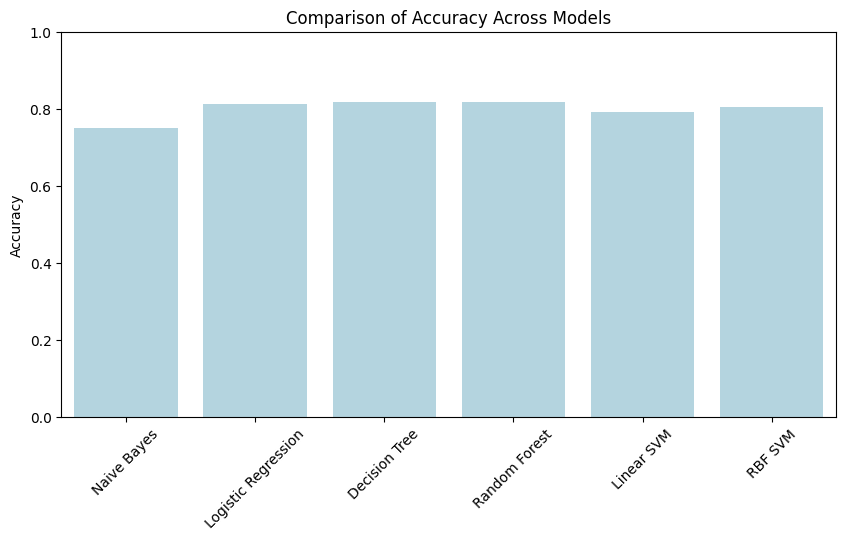

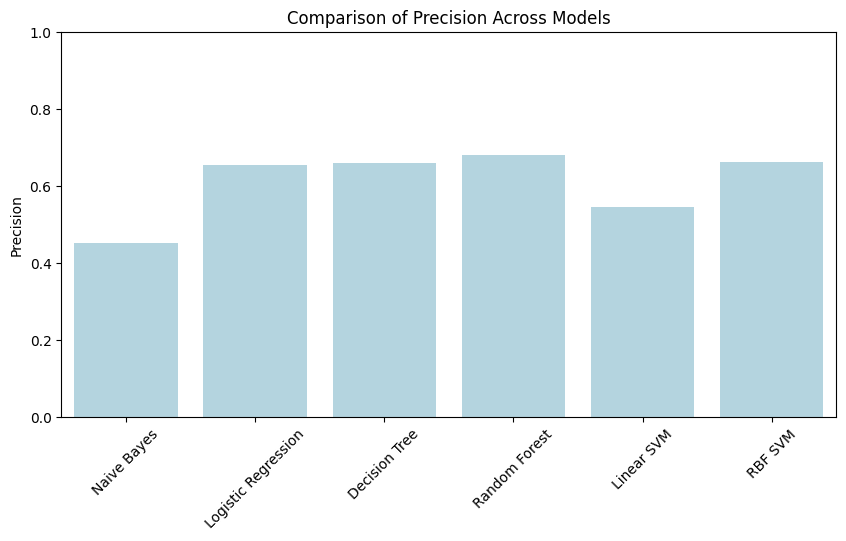

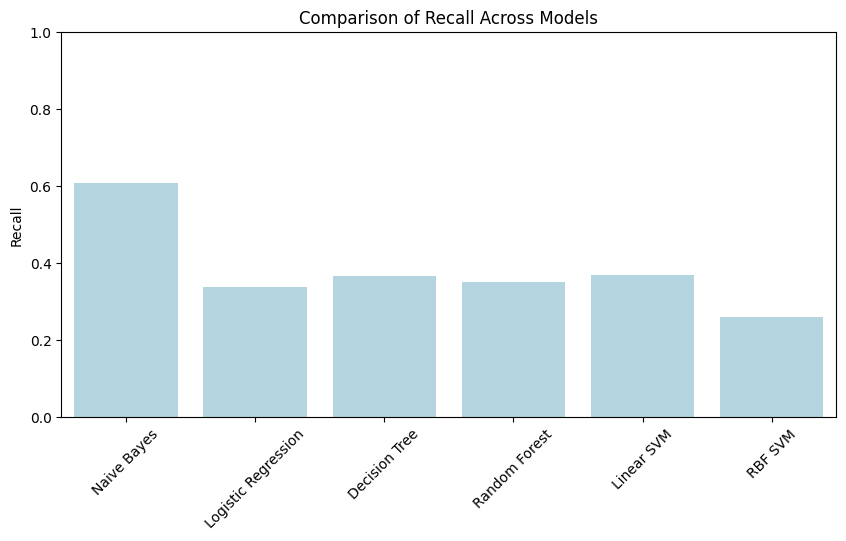

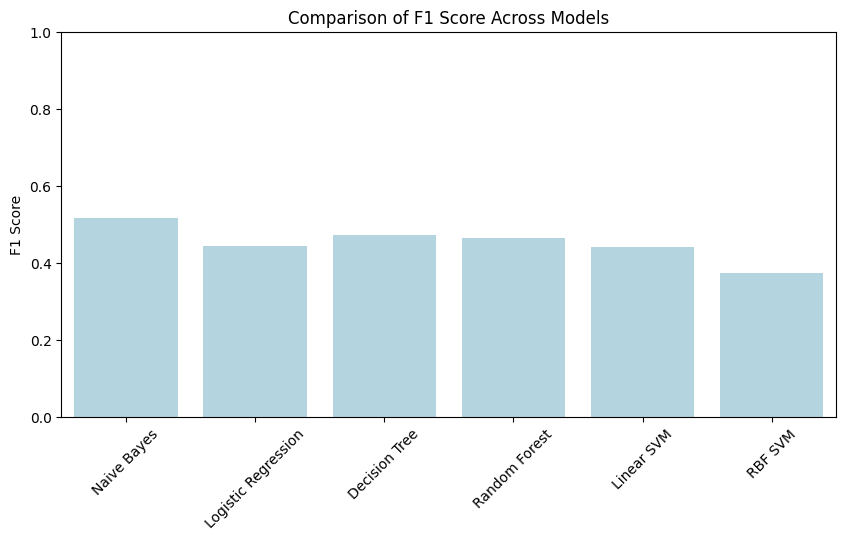

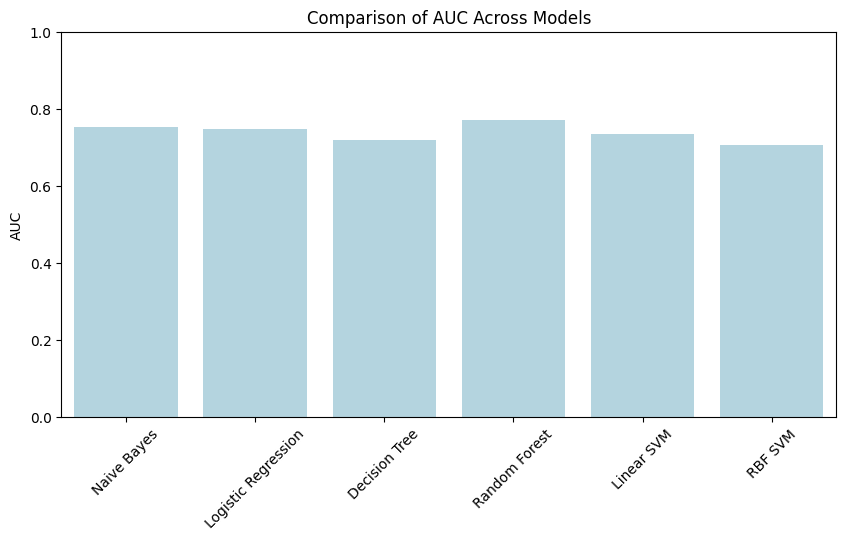

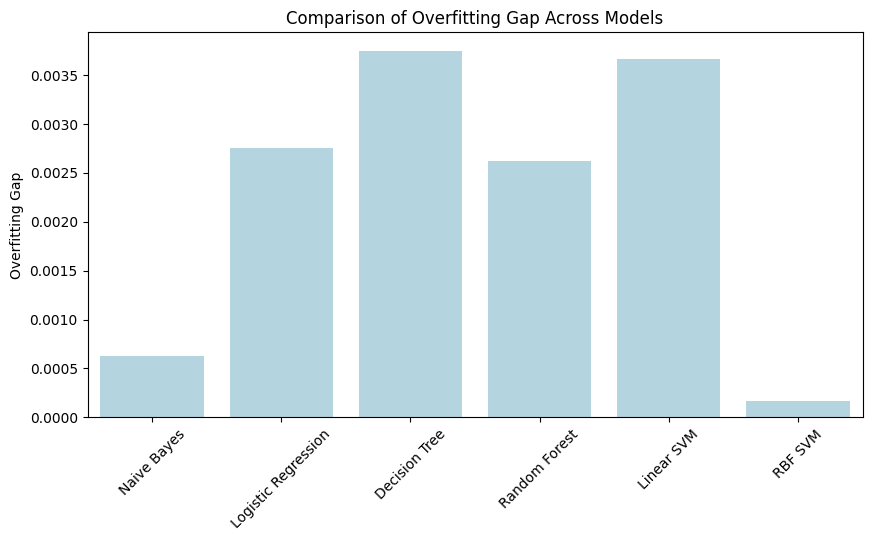

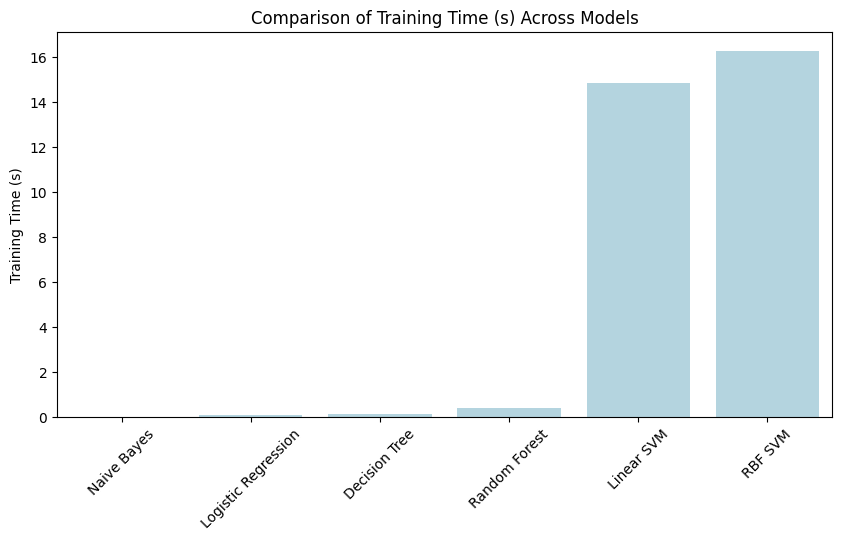

,Accuracy,Precision,Recall,F1 Score,AUC,Overfitting Gap,Training Time (s),Points
Model,,,,,,,,
Naive Bayes,0.750500,0.452354,0.608139,0.518804,0.752822,0.000625,0.029257,3
Random Forest,0.820167,0.680233,0.352675,0.464516,0.771824,0.002625,0.419588,3
RBF SVM,0.807167,0.662214,0.261492,0.374932,0.706599,0.000167,16.283882,1
Logistic Regression,0.814167,0.654971,0.337604,0.445549,0.749761,0.002750,0.118654,0
Decision Tree,0.818333,0.660352,0.367747,0.472410,0.719883,0.003750,0.145683,0
Linear SVM,0.793000,0.547275,0.370761,0.442049,0.735357,0.003667,14.840527,0


,Top1,Top2,Difference
Accuracy,Random Forest,Decision Tree,0.001833
Precision,Random Forest,RBF SVM,0.018019
Recall,Naive Bayes,Linear SVM,0.237378
F1 Score,Naive Bayes,Decision Tree,0.046394
AUC,Random Forest,Naive Bayes,0.019002
Overfitting Gap,RBF SVM,Naive Bayes,-0.000458
Training Time (s),Naive Bayes,Logistic Regression,-0.089396


In [ ]:
models_names = ["Naive Bayes", "Logistic Regression", "Decision Tree", "Random Forest",
                "Linear SVM", "RBF SVM"]

# Organize metrics in a dictionary
metrics_dict = {
    "Accuracy": [accuracy_nb, accuracy_lr, accuracy_dt, accuracy_rf, accuracy_svm_linear, accuracy_svm_rbf],
    "Precision": [precision_nb, precision_lr, precision_dt, precision_rf, precision_svm_linear, precision_svm_rbf],
    "Recall": [recall_nb, recall_lr, recall_dt, recall_rf, recall_svm_linear, recall_svm_rbf],
    "F1 Score": [f1_nb, f1_lr, f1_dt, f1_rf, f1_svm_linear, f1_svm_rbf],
    "AUC": [auc_nb, auc_lr, auc_dt, auc_rf, auc_svm_linear, auc_svm_rbf],
    "Overfitting Gap": [overfit_gap_nb, overfit_gap_lr, overfit_gap_dt, overfit_gap_rf, overfit_gap_svm_linear, overfit_gap_svm_rbf],
    "Training Time (s)": [total_time_nb, total_time_lr, total_time_dt, total_time_rf, total_time_svm_linear, total_time_svm_rbf]
}

# Plot each metric in a graph
for metric, values in metrics_dict.items():
    plt.figure(figsize=(10,5))
    sns.barplot(x=models_names, y=values, color="lightblue")
    plt.title(f"Comparison of {metric} Across Models")
    plt.ylabel(metric)
    if metric not in ["Overfitting Gap", "Training Time (s)"]:
        plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.show()
    print()

# Create a summary DataFrame
metrics_summary = pd.DataFrame({
    "Model": models_names,
    "Accuracy": metrics_dict["Accuracy"],
    "Precision": metrics_dict["Precision"],
    "Recall": metrics_dict["Recall"],
    "F1 Score": metrics_dict["F1 Score"],
    "AUC": metrics_dict["AUC"],
    "Overfitting Gap": metrics_dict["Overfitting Gap"],
    "Training Time (s)": metrics_dict["Training Time (s)"]
})

# Set the model name as index
metrics_summary.set_index("Model", inplace=True)

# Initialize a "Points" column
metrics_summary["Points"] = 0

# Assign points based on each metric
for metric in metrics_summary.columns[:-1]:
    if metric in ["Overfitting Gap", "Training Time (s)"]:
        best_model = metrics_summary[metric].idxmin()
    else:
        best_model = metrics_summary[metric].idxmax()

    metrics_summary.loc[best_model, "Points"] += 1

display(metrics_summary.sort_values("Points", ascending=False))
print()

# Compute top1-top2 differences
diff_summary = metrics_summary.copy()
metric_cols = [col for col in diff_summary.columns if col not in ["Points"]]

top2_diff_info = {}

for metric in metric_cols:
    if metric in ["Overfitting Gap", "Training Time (s)"]:
        ascending = True
    else:
        ascending = False

    sorted_df = diff_summary.sort_values(by=metric, ascending=ascending)

    top1_model = sorted_df.index[0]
    top2_model = sorted_df.index[1]

    top1_value = sorted_df.loc[top1_model, metric]
    top2_value = sorted_df.loc[top2_model, metric]
    diff = top1_value - top2_value

    top2_diff_info[metric] = {
        "Top1": top1_model,
        "Top2": top2_model,
        "Difference": diff
    }

top2_diff_df = pd.DataFrame(top2_diff_info).T
top2_diff_df = top2_diff_df[["Top1", "Top2", "Difference"]]

display(top2_diff_df)